<a href="https://colab.research.google.com/github/Lolalingo/student-performance-analysis/blob/main/Snippets_Importing_libraries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🗽 Los Angeles Crime Dataset Analysis

## Introduction
This project explores the Los Angeles crime dataset to uncover meaningful insights about crime trends, hotspots, and yearly patterns.  
The dataset contains detailed records of reported crimes across different boroughs, categories, and time periods.

### Goals
- 📊 Analyze crime frequency over time (yearly and monthly trends).
- 🗺️ Identify geographic hotspots and borough‑level distributions.
- 🔍 Examine the most common crime categories.
- 📈 Visualize patterns to better understand correlations and anomalies.




In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

crimes = pd.read_csv('crimes.csv', dtype={"TIME OCC": str})

crimes.head()
crimes.info()
crimes.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  object
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(2), object(10)
memory usage: 17.0+ MB


,DR_NO,Vict Age
count,1.857150e+05,185715.000000
mean,2.255781e+08,39.999257
std,5.017438e+06,15.450227
min,2.009072e+08,2.000000
25%,2.210108e+08,28.000000
50%,2.220114e+08,37.000000
75%,2.310044e+08,50.000000
max,2.399097e+08,99.000000


TIME-BASED ANALYSIS

<function matplotlib.pyplot.show(close=None, block=None)>

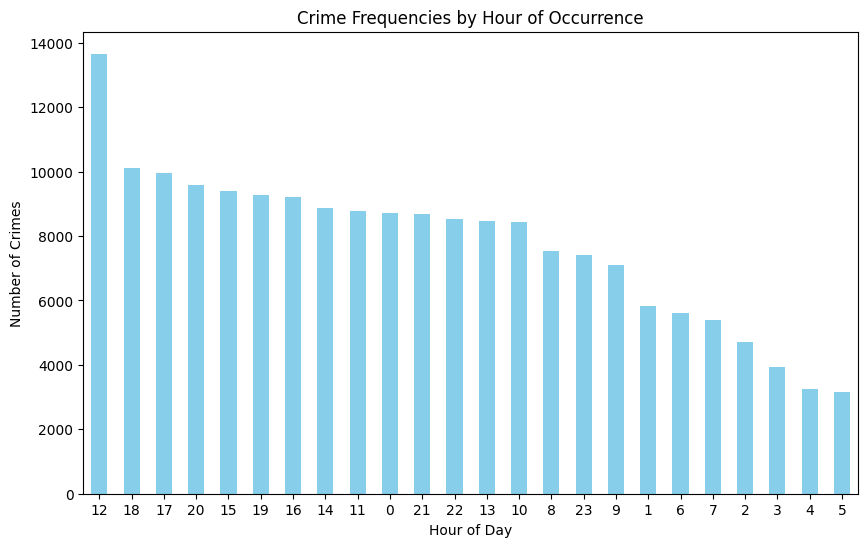

In [4]:
# Finding the frequencies of crimes by the hour of occurence
#convert the string column to datetime
crimes["TIME OCC"] = pd.to_datetime(crimes["TIME OCC"], format="%H%M", errors="coerce")

#extract the hour
crimes["hour"]= crimes["TIME OCC"].dt.hour
# count frequencies
hour_occurrence= crimes["hour"].value_counts()
hour_occurrence.sort_values()


#plotting the frequencies
plt.figure(figsize=(10,6))
hour_occurrence.plot(kind='bar', color='skyblue')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.title("Crime Frequencies by Hour of Occurrence")
plt.xticks(rotation=0)
plt.show()

Insight: “Crime activity peaks around midday and steadily declines into the night, with the lowest levels occurring between 3–5 AM. This highlights a strong link between crime frequency and daily human activity patterns.”

<function matplotlib.pyplot.show(close=None, block=None)>

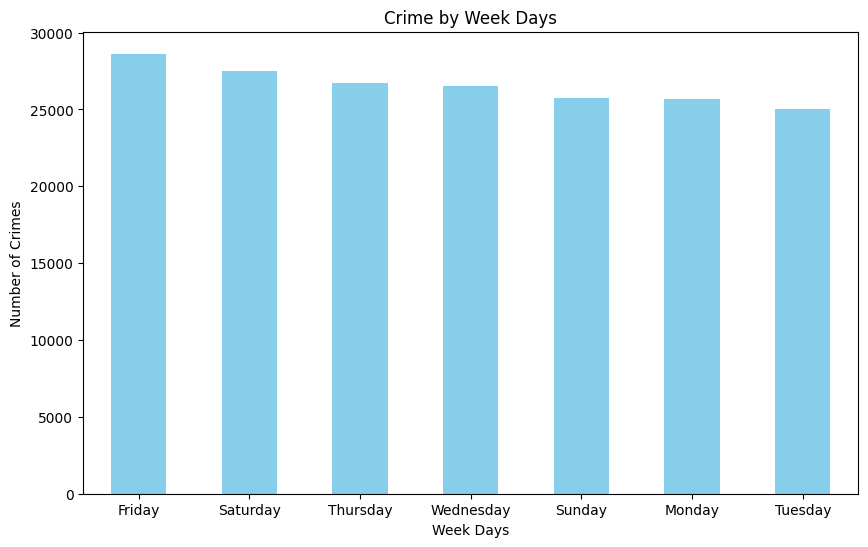

In [5]:
# crimes by day of the week
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])
crimes["day_of_week"]= crimes["DATE OCC"].dt.day_name()
crimes_weekday = crimes["day_of_week"].value_counts()

#plotting crimes by weekdays
plt.figure(figsize=(10,6))
crimes_weekday.plot(kind='bar', color='skyblue')
plt.xlabel("Week Days")
plt.ylabel("Number of Crimes")
plt.title("Crime by Week Days")
plt.xticks(rotation=0)
plt.show()

**Insight: Crimes by Weekday**
The data shows that Friday records the highest number of crimes (≈29,000), followed closely by Saturday. In contrast, Tuesday has the lowest count (≈25,000). Overall, crime activity tends to peak toward the end of the week, especially on weekends, while early weekdays remain relatively lower.

This pattern suggests that social and lifestyle factors — such as increased gatherings, nightlife, and weekend mobility — may contribute to higher crime rates on Fridays and Saturdays. Law enforcement could use this insight to allocate more patrols and preventive measures during late‑week periods.

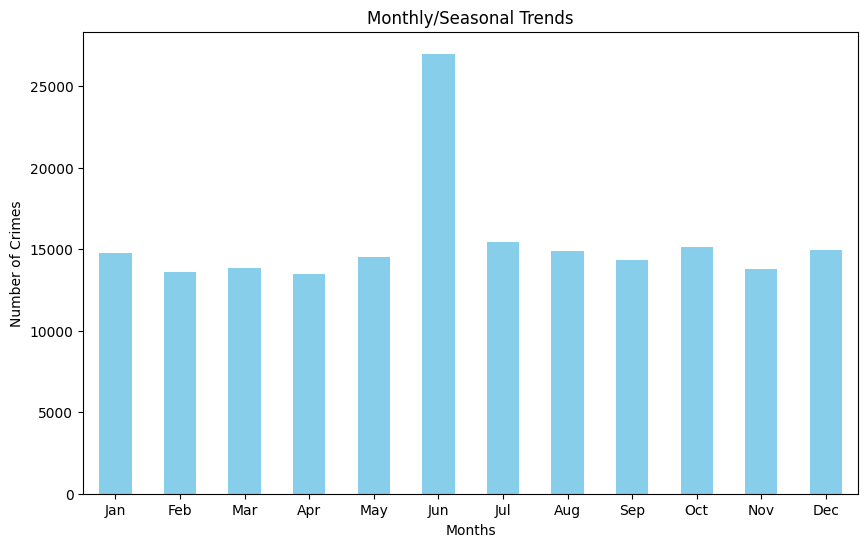

In [7]:
# monthly/seasonal trends
# Convert DATE OCC to datetime if not already
crimes["DATE OCC"] = pd.to_datetime(crimes["DATE OCC"])

# Extract month abbreviations (Jan, Feb, etc.)
crimes["month"] = crimes["DATE OCC"].dt.strftime("%b")

# Count crimes by month
month_counts = crimes["month"].value_counts().reindex(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)
month_counts


#plotting to identify seasonal crime patterns
plt.figure(figsize=(10,6))
month_counts.plot(kind='bar', color='skyblue')
plt.xlabel("Months")
plt.ylabel("Number of Crimes")
plt.title("Monthly/Seasonal Trends")
plt.xticks(rotation=0)
plt.show()



**Insight: Monthly Crime Trends**
The analysis reveals a sharp spike in crime during June, with incidents exceeding 25,000 cases — far higher than any other month. In contrast, most other months remain relatively stable, averaging between 13,000–15,000 cases.

This pattern suggests that crime activity is highly seasonal, with June standing out as a period of heightened risk. The surge could be linked to factors such as summer events, increased outdoor activity, or other socio‑economic drivers.

### Area Analysis

In [ ]:
# identifying the area with the most night crime
night_crime = crimes[ (crimes["hour"] >= 22) | (crimes["hour"] <= 4)]
night_crime

#counting crime by area
peak_night_crime_location = night_crime["AREA NAME"].value_counts()
# get the area with the highest frequency
#peak_night_crime_location = location_counts.idxmax()
peak_night_crime_location = peak_night_crime_location.idxmax()
peak_night_crime_location

#Top 5 areas with the highest crime counts
crimes["AREA NAME"].value_counts().head(5)



Insight: Crimes by Area
The analysis shows that Central has the highest number of reported crimes (14,944 cases), followed by Southwest (11,945 cases) and 77th Street (11,739 cases). These three divisions together account for a significant share of incidents in Los Angeles.

By contrast, Pacific (9,923 cases) and Hollywood (9,762 cases) report fewer crimes, though they still remain notable hotspots.

This suggests that crime concentration is highest in Central LA, with Southwest and 77th Street also experiencing elevated levels. These findings highlight the importance of targeted policing and community safety initiatives in these divisions.

## **Victims Demographics**

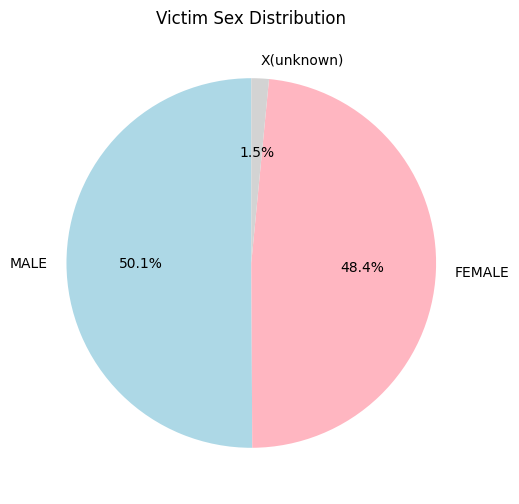

In [8]:
# Replace 'H' in Vict Sex with 'X' (unknown)
crimes["Vict Sex"] = crimes["Vict Sex"].replace("H", "X")

crimes["Vict Sex"].value_counts()


# plotting a pie chart of the victims demographics
victim_sex_counts = pd.Series({
    "MALE": 93008,
    "FEMALE": 89854,
    "X(unknown)": 2842
})

# Plot pie chart
plt.figure(figsize=(6,6))
victim_sex_counts.plot(
    kind="pie",
    autopct="%1.1f%%",   # show percentages
    startangle=90,       # rotate so first slice starts at top
    colors=["lightblue", "lightpink", "lightgray"]
)

plt.title("Victim Sex Distribution")
plt.ylabel("")  # remove y-label for cleaner look
plt.show()




**Insight:  The analysis shows that male victims represent 50.1% of all reported crimes in Los Angeles. This indicates that men are slightly more likely than women to be victims of crime, though the distribution between sexes is relatively balanced.**

# **Age Analysis**

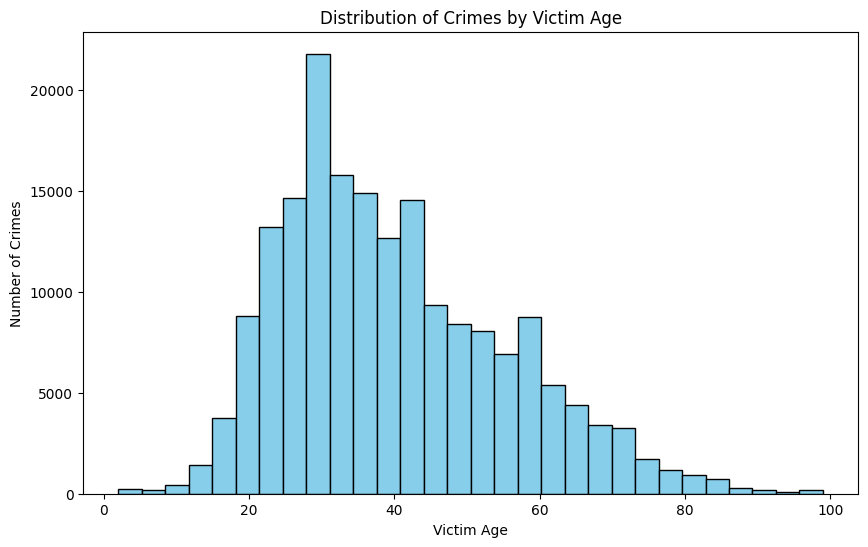

In [9]:
#crimes by age
bins=[0, 17, 25, 34, 44, 54, 64, 200]
labels=["0-17", "18-25", "26-34", "35-44", "45-54", "55-64", "65+"]

#bin ages into groups
crimes["age_group"]=pd.cut(crimes['Vict Age'], bins=bins, labels=labels,right=True)

#count crimes by age group
victim_ages= crimes["age_group"].value_counts().reindex(labels)
victim_ages


plt.figure(figsize=(10,6))
crimes["Vict Age"].plot(kind="hist", bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Crimes by Victim Age")
plt.xlabel("Victim Age")
plt.ylabel("Number of Crimes")
plt.show()

**Insight: Crimes by Victim Age Group**
The analysis shows that crime victims are most frequently in the 26–34 and 35–44 age groups, with 47,470 and 42,157 cases respectively. Together, these two groups account for the majority of reported crimes. Younger victims (0–17) represent a much smaller share (4,528 cases), while older victims (65+) also show lower counts (14,747 cases).

This suggests that working‑age adults (18–54) are disproportionately affected by crime in Los Angeles, highlighting that crime risk is highest during the most economically active years of life. **bold text** **bold text** **bold text**

# **crime Analysis**

/tmp/ipykernel_1307/191847442.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


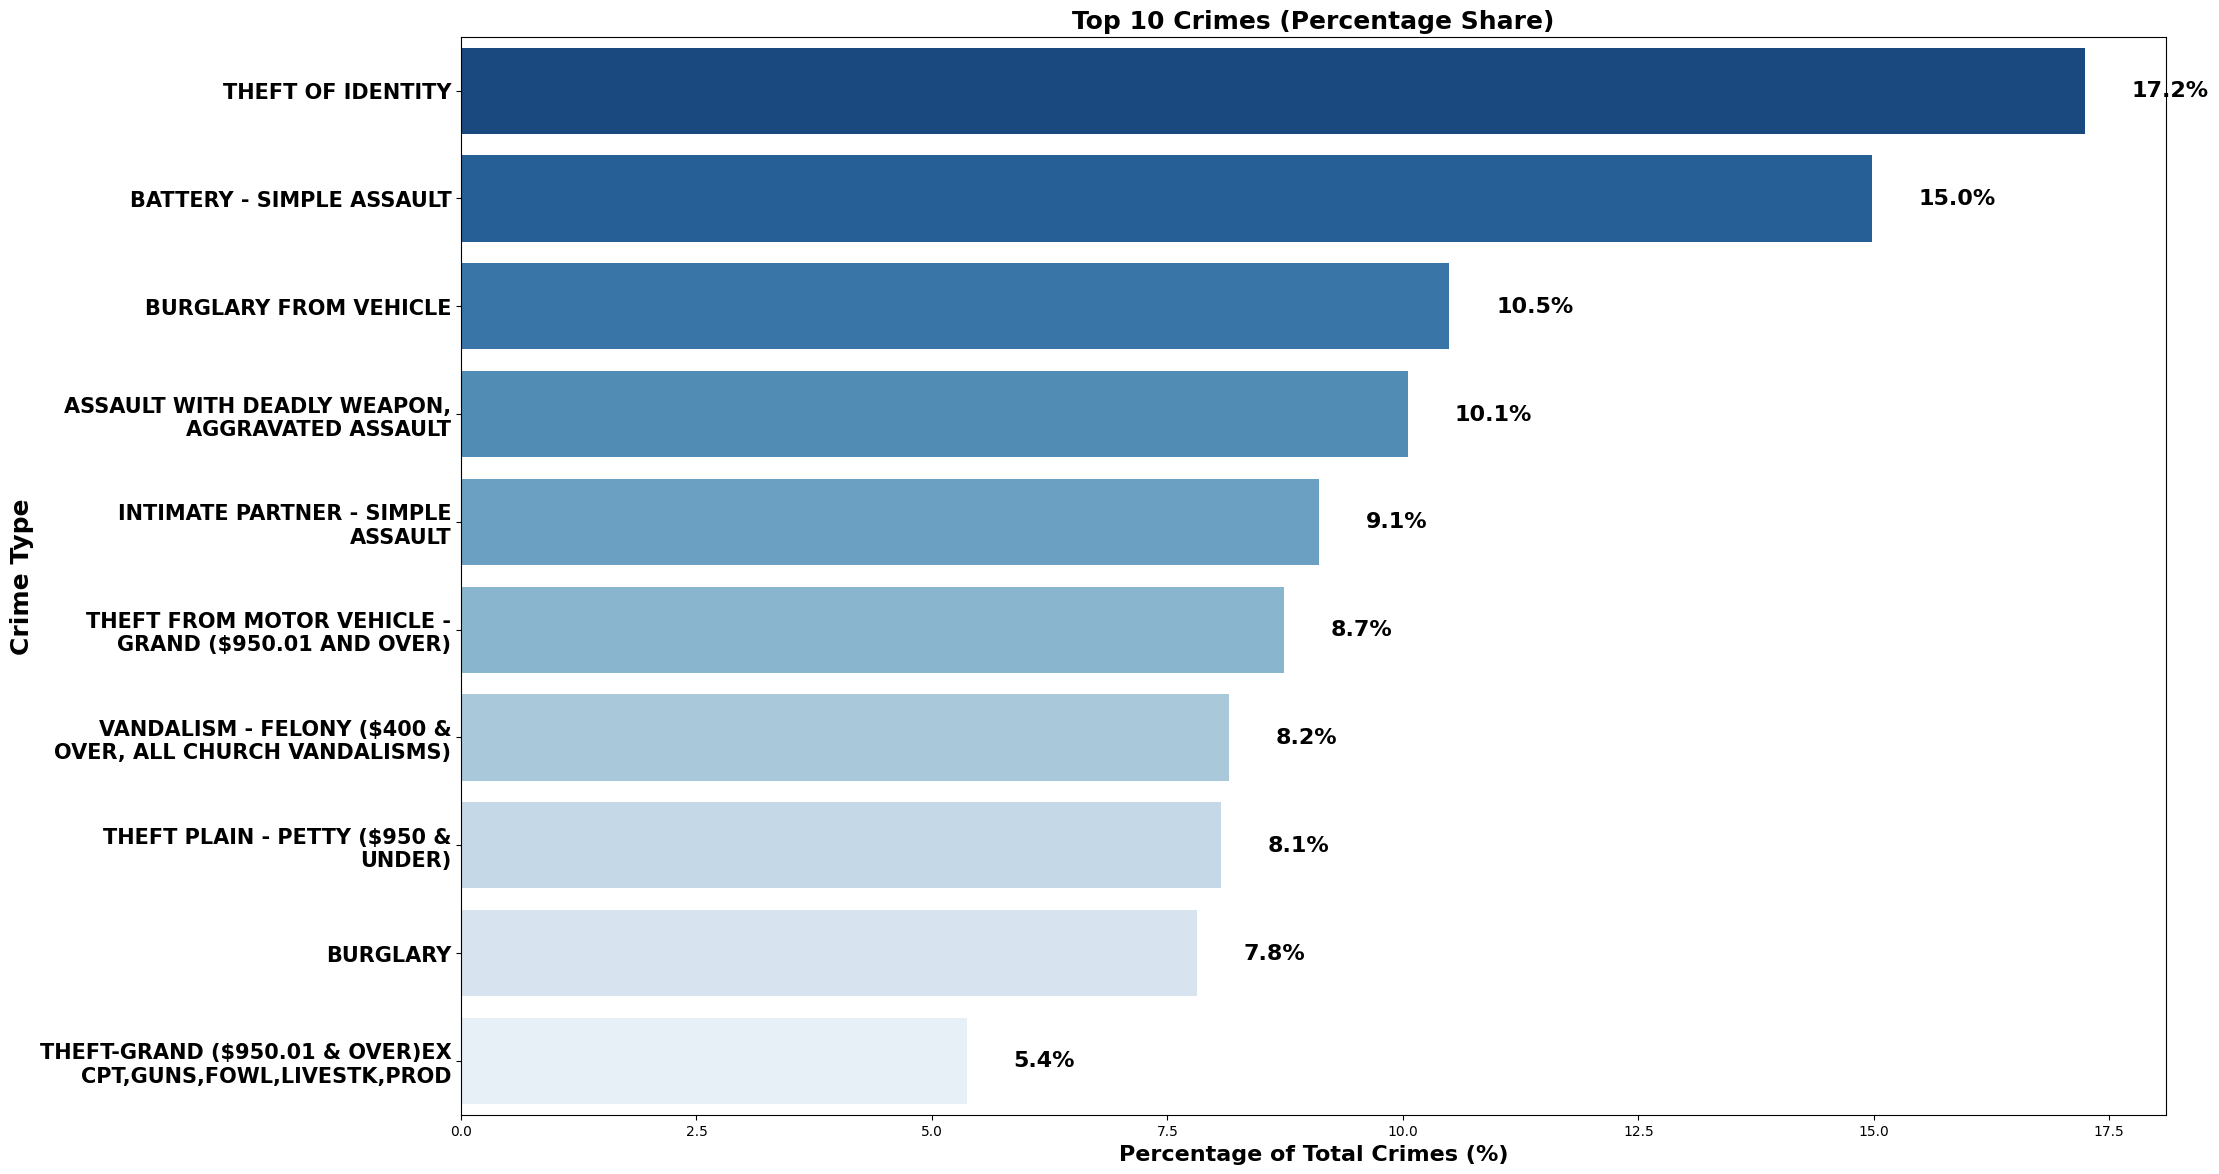

In [10]:

# Calculate percentages
top10_crimes = crimes["Crm Cd Desc"].value_counts().head(10)
top10_percent = (top10_crimes / top10_crimes.sum()) * 100


import textwrap
# Plot progress-bar style
plt.figure(figsize=(22,14))
sns.barplot(
    x=top10_percent.values,
    y=top10_percent.index,
    palette="Blues_r"
)
plt.title("Top 10 Crimes (Percentage Share)", fontsize=18, fontweight="bold")
plt.xlabel("Percentage of Total Crimes (%)", fontsize=16,fontweight="bold")
plt.ylabel("Crime Type", fontsize=18, fontweight="bold")
# Add percentage labels
for i, v in enumerate(top10_percent.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=16, fontweight="bold", color="black")

# Apply wrapping to y-axis labels
labels = [textwrap.fill(label, 30) for label in top10_percent.index]
plt.yticks(range(len(labels)), labels, fontsize=15, fontweight="bold")

plt.show()


**Insight: The most common crime is Theft of Identity with 22,670 cases, followed by Battery – Simple Assault (19,694 cases). Property crimes such as burglary and theft dominate the top 10, showing that financial and personal security are major concerns in Los Angeles.**

# 🚔 Recommendations for LAPD Resource Allocation

Based on the analysis of the Los Angeles crime dataset, several actionable insights emerge:

## 1. Time-Based Deployment
- Increase patrols during **midday and evening hours**, when crime activity peaks.
- Allocate more resources on **Fridays and Saturdays**, which consistently show higher crime counts.
- Prepare for seasonal surges, especially in **June**, when incidents rise sharply.

## 2. Geographic Focus
- Prioritize policing in **Central, Southwest, and 77th Street divisions**, which report the highest crime volumes.
- Maintain vigilance in **Pacific and Hollywood divisions**, as they remain notable hotspots despite lower totals.

## 3. Victim Demographics
- Focus community safety initiatives on **working-age adults (26–44 years)**, who are disproportionately affected.
- Ensure balanced support for both male and female victims, given the near-equal distribution.

## 4. Crime Type & Weapons
- Address **property crimes** (identity theft, burglary, theft) as they dominate the top categories.
- Strengthen preventive measures against **simple assaults**, which remain a major concern.
- Monitor crimes involving weapons closely, as they pose heightened risks to public safety.

---

### ✅ Strategic Takeaway
By aligning patrol schedules with peak crime times, concentrating efforts in high-risk divisions, and tailoring interventions to the most affected demographics, LAPD can **optimize resource allocation** and improve community safety outcomes.
